# 05 — Round-Level Factors
Halftime score as predictor, win streaks, side advantages.


In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from eda.utils import load_tables, enrich_matches, get_working_matches, get_completed_maps, savefig

tables = load_tables()
matches = enrich_matches(tables['matches'])
working = get_working_matches(matches)
comp_maps = get_completed_maps(tables['maps'], working)


In [2]:
rounds = tables['map_rounds']
rounds_w = rounds.merge(comp_maps[['map_id','tier','map_winner_id']], on='map_id', how='inner')
print(f"Working rounds: {len(rounds_w):,}")


Working rounds: 756,897


P(map win | led at halftime) by tier:
tier
tier1    0.788627
tier2    0.776644
Name: half_leader_won, dtype: float64
Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/05_halftime_predictor.png


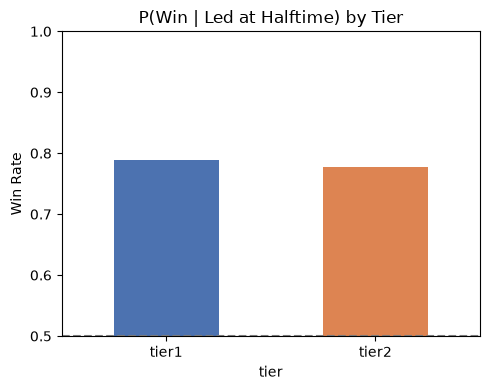

In [3]:
# 5a. Halftime score as predictor
# Standard: first half = rounds 1–12
first_half = rounds_w[rounds_w['round_num'] <= 12]
half_score = first_half.groupby(['map_id','winning_team_id','tier']).size().reset_index(name='half_wins')
half_leader = half_score.loc[half_score.groupby('map_id')['half_wins'].idxmax()]
half_leader = half_leader.merge(comp_maps[['map_id','map_winner_id']], on='map_id')
half_leader['half_leader_won'] = (half_leader['winning_team_id'] == half_leader['map_winner_id'])
leader_wr = half_leader.groupby('tier')['half_leader_won'].mean()
print("P(map win | led at halftime) by tier:")
print(leader_wr)

fig, ax = plt.subplots(figsize=(5,4))
leader_wr.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'])
ax.axhline(0.5, color='gray', linestyle='--')
ax.set_ylim(0.5, 1.0)
ax.set_title('P(Win | Led at Halftime) by Tier')
ax.set_ylabel('Win Rate')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
savefig(fig, '05_halftime_predictor')
plt.show()


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/05_win_streaks.png


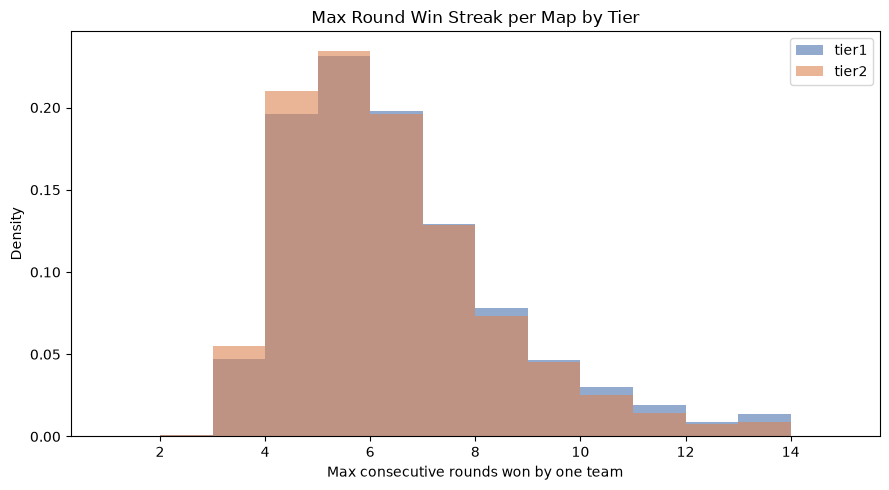

In [4]:
# 5b. Win streaks: max consecutive rounds by same team per map
def max_streak(group):
    teams = group.sort_values('round_num')['winning_team_id'].tolist()
    if not teams: return 0
    max_s, cur_s = 1, 1
    for i in range(1, len(teams)):
        cur_s = cur_s + 1 if teams[i] == teams[i-1] else 1
        max_s = max(max_s, cur_s)
    return max_s

streak_df = (rounds_w.groupby(['map_id','tier'])
             .apply(max_streak, include_groups=False)
             .reset_index(name='max_streak'))

fig, ax = plt.subplots(figsize=(9,5))
for tier, color in [('tier1','#4C72B0'),('tier2','#DD8452')]:
    data = streak_df[streak_df['tier']==tier]['max_streak']
    ax.hist(data, bins=range(1,16), alpha=0.6, color=color, label=tier, density=True)
ax.set_title('Max Round Win Streak per Map by Tier')
ax.set_xlabel('Max consecutive rounds won by one team')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
savefig(fig, '05_win_streaks')
plt.show()


In [5]:
# 5c. Side win rates by tier
side_wr = (rounds_w.groupby('tier')['winning_side']
           .apply(lambda s: pd.Series({'ct': (s=='ct').mean(), 't': (s=='t').mean()}))
           .unstack())
print("Round win rate by side and tier:")
print(side_wr.to_string())


Round win rate by side and tier:
             ct         t
tier                     
tier1  0.499983  0.500017
tier2  0.492679  0.507321


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/05_deficit_win_probability.png


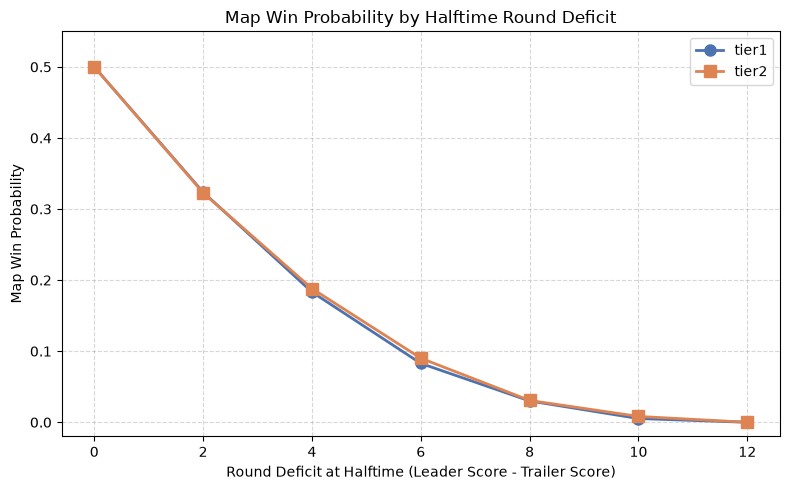

=== Comeback Rates for Trailing Teams ===
TIER1 Comeback Rate: 17.0148% (2566/15081)
TIER2 Comeback Rate: 18.0278% (2905/16114)
Chi-square test p-value: 0.01948


In [6]:
# %%
# 5d. Win probability by halftime round deficit
import seaborn as sns
from scipy.stats import chi2_contingency

# Re-calculate halftime scores and deficits, explicitly merging team IDs
first_half = rounds_w[rounds_w['round_num'] <= 12].merge(
    comp_maps[['map_id', 'team1_id', 'team2_id']], on='map_id', how='inner'
)
team1_wins = first_half[first_half['winning_team_id'] == first_half['team1_id']].groupby('map_id').size().reset_index(name='team1_half_score')

map_scores = comp_maps[['map_id', 'tier', 'team1_id', 'team2_id', 'map_winner_id']].merge(team1_wins, on='map_id', how='inner')
map_scores['team1_won'] = (map_scores['map_winner_id'] == map_scores['team1_id']).astype(int)

team2_scores = map_scores.copy()
team2_scores['half_score'] = 12 - team2_scores['team1_half_score']
team2_scores['won'] = 1 - team2_scores['team1_won']

team1_scores = map_scores.copy()
team1_scores['half_score'] = team1_scores['team1_half_score']
team1_scores['won'] = team1_scores['team1_won']

all_team_scores = pd.concat([
    team1_scores[['map_id', 'tier', 'half_score', 'won']],
    team2_scores[['map_id', 'tier', 'half_score', 'won']]
])

all_team_scores['deficit'] = 12 - 2 * all_team_scores['half_score']
trailing = all_team_scores[all_team_scores['deficit'] >= 0].copy()

# Summary table
deficit_summary = trailing.groupby(['tier', 'deficit'])['won'].mean().reset_index()

# Plot line chart
fig, ax = plt.subplots(figsize=(8, 5))
for tier, color, marker in [('tier1', '#4C72B0', 'o'), ('tier2', '#DD8452', 's')]:
    data = deficit_summary[deficit_summary['tier'] == tier]
    ax.plot(data['deficit'], data['won'],
            marker=marker, label=tier, color=color, linewidth=2, markersize=8)
    
ax.set_title('Map Win Probability by Halftime Round Deficit')
ax.set_xlabel('Round Deficit at Halftime (Leader Score - Trailer Score)')
ax.set_ylabel('Map Win Probability')
ax.set_xticks(range(0, 13, 2))
ax.set_ylim(-0.02, 0.55)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
savefig(fig, '05_deficit_win_probability')
plt.show()

# Print statistics
print("=== Comeback Rates for Trailing Teams ===")
non_zero = all_team_scores[all_team_scores['deficit'] > 0]
for tier in ['tier1', 'tier2']:
    sub = non_zero[non_zero['tier'] == tier]
    comeback_rate = sub['won'].mean()
    print(f"{tier.upper()} Comeback Rate: {comeback_rate:.4%} ({sub['won'].sum()}/{len(sub)})")
    
# Chi-square test
contingency = pd.crosstab(non_zero['tier'], non_zero['won'])
chi2, p, dof, ex = chi2_contingency(contingency)
print(f"Chi-square test p-value: {p:.5f}")
